
#Testing 2nd Hypthesis for Larry Sanders example

##Large ratio between sqrf_lot / sqrf_living means that house is isolated aka has large garden


Importing libraries we will need

In [134]:
!pip install scikit-learn

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture
from scipy.stats import gaussian_kde
from matplotlib.patches import Wedge, Circle
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap

Reading clean_king_county_house_details
check info again to get an overview

In [136]:
df_clean_details = pd.read_csv('data/clean_king_county_house_details.csv', sep=";")
df_clean_details.head(20)
df_clean_sales = pd.read_csv('data/clean_king_county_house_sales.csv', sep=";")
df_clean_sales.head(20)



,date,price,house_id,id
0,2014-10-13,221900.0,7129300520,1
1,2014-12-09,538000.0,6414100192,2
2,2015-02-25,180000.0,5631500400,3
3,2014-12-09,604000.0,2487200875,4
4,2015-02-18,510000.0,1954400510,5
5,2014-05-12,1230000.0,7237550310,6
6,2014-06-27,257500.0,1321400060,7
7,2015-01-15,291850.0,2008000270,8
8,2015-04-15,229500.0,2414600126,9
9,2015-03-12,323000.0,3793500160,10


In [137]:
#Testing if when there is not basement that living space (sqft_living) is sqft_above
#IMPORTANT: Still it is not normalized to the floors meaning sqft_living is not house
sqft_above_eq_basement_boolean = (df_clean_details.loc[df_clean_details['sqft_basement'] == 0, 'sqft_above']
 ==
 df_clean_details.loc[df_clean_details['sqft_basement'] == 0, 'sqft_living']).all()

print(f'If the house has no basement the living space equals varialbe sqft_above: {sqft_above_eq_basement_boolean}')

If the house has no basement the living space equals varialbe sqft_above: True


In [138]:
#but interesting, if there is a basement this is equivalent to house foot print 
#to test this we check if sqft_basement is never larger than sqft_lot
sqft_basement_smaller_lot = (df_clean_details.loc[df_clean_details['sqft_basement'] > 5, 'sqft_basement']
<
 df_clean_details.loc[df_clean_details['sqft_basement'] > 5, 'sqft_lot']).all()

nmbr_sqft_basement_smaller_lot = (df_clean_details.loc[df_clean_details['sqft_basement'] > 5, 'sqft_basement']
<
 df_clean_details.loc[df_clean_details['sqft_basement'] > 5, 'sqft_lot']).count()

print(f'All appartments with basement have a larger lot sqft value than basement space: {sqft_basement_smaller_lot}, and we have so many house in this category: {nmbr_sqft_basement_smaller_lot }')

All appartments with basement have a larger lot sqft value than basement space: True, and we have so many house in this category: 8252


In [139]:
#ok - lets check if house with only one floor always have a smaller footprint than lot
mask = (df_clean_details['floors'] == 1) & (df_clean_details['sqft_basement'] == 0)

sqft_living_smaller_lot_floors1 = (
    df_clean_details.loc[mask, 'sqft_living'] <
    df_clean_details.loc[mask, 'sqft_lot']
).all()

nmbr_sqft_living_smaller_lot_floors1 = sqft_living_smaller_lot_floors1 = (
    df_clean_details.loc[mask, 'sqft_living'] <=
    df_clean_details.loc[mask, 'sqft_lot']
).sum()


nmbr_sqft_living_larger_lot_floors1 = (
    df_clean_details.loc[mask, 'sqft_living'] >
    df_clean_details.loc[mask, 'sqft_lot']
).sum()

print(
f'All houses with one floor and no basement have a smaller living space than the lot: '
f'{sqft_living_smaller_lot_floors1} ({nmbr_sqft_living_larger_lot_floors1 } larger than ratio 1). Number of such houses: {nmbr_sqft_living_smaller_lot_floors1}'
)


All houses with one floor and no basement have a smaller living space than the lot: 4974 (1 larger than ratio 1). Number of such houses: 4974


In [140]:
#normalize the living space by floors
df_clean_details['norm_sqft_living'] = df_clean_details['sqft_living']/df_clean_details['floors']

#build the ratio of sqft_lot / norm_sqft_norm
df_clean_details['ratio_lot_norm_living'] = df_clean_details['sqft_lot']/df_clean_details['norm_sqft_living']

nmbr_house_ratio_smaller_1 = (df_clean_details['ratio_lot_norm_living'] < 1).sum()

fraction = nmbr_house_ratio_smaller_1 / df_clean_details.shape[0]

print(f'The number {fraction} of house that have a ratio smaller than 1')

df_clean_details['ratio_lot_norm_living'].nlargest(10)


The number 0.00037348272642390287 of house that have a ratio smaller than 1


7485     1640.554930
27       1270.276154
701      1000.518750
2993      688.034544
5484      674.735204
18124     562.458772
5277      535.324585
15174     521.484350
5957      519.560622
4174      508.222333
Name: ratio_lot_norm_living, dtype: float64

In [141]:
data = df_clean_details['ratio_lot_norm_living']

# create logarithmic bins
bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 50)

plt.hist(data, bins=bins)

plt.yscale('log')
plt.xscale('log')

plt.xlabel('Lot size / house footprint ratio')
plt.ylabel('Number of houses')
plt.title('Log–log histogram of ratio_lot_norm_living')

plt.show()6

SyntaxError: invalid syntax (3650801109.py, line 15)

Highest-density center: long=-122.35200, lat=47.67980
Max estimated density: 14.813431

Mean ratio_lot_norm_living per ring (no filtering):
Ring 1: mean=4.67, n=7388
Ring 2: mean=8.58, n=6905
Ring 3: mean=13.95, n=5697
Ring 4: mean=30.73, n=1082
Ring 5: mean=34.21, n=330
Ring 6: mean=12.44, n=3
Ring 7: mean=29.92, n=15


/var/folders/5r/hdlyzsgx0xj42yqd4vbnps3m0000gn/T/ipykernel_14877/269426091.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('Greens')


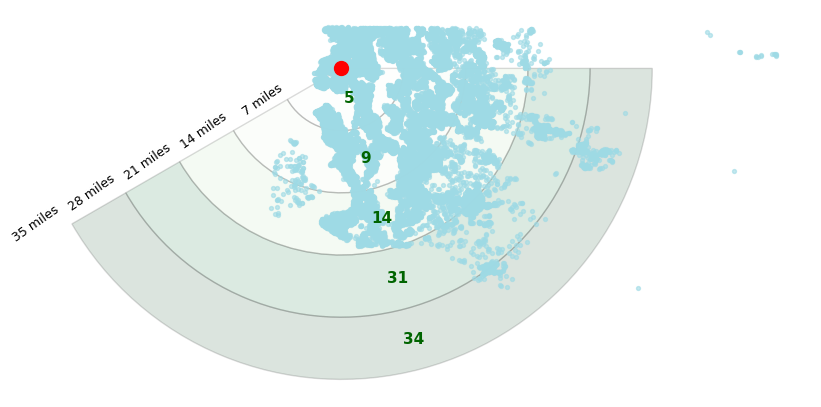


Houses with ratio > 14 inside first circle: 114


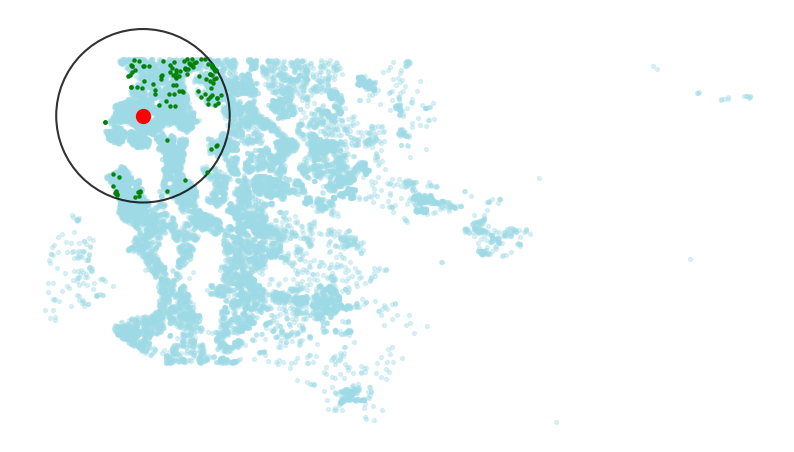

In [ ]:

# -----------------------------------
# settings
# -----------------------------------
n_rings = 7                  # keep for calculation
n_plot_rings = n_rings - 2   # do NOT plot outermost ring
green_threshold = 14

# -----------------------------------
# 1. highest-density point by KDE
# -----------------------------------
xy = np.vstack([
    df_clean_details['long'],
    df_clean_details['lat']
])

kde = gaussian_kde(xy)
density = kde(xy)

idx_center = density.argmax()
center_long = df_clean_details['long'].iloc[idx_center]
center_lat = df_clean_details['lat'].iloc[idx_center]

print(f"Highest-density center: long={center_long:.5f}, lat={center_lat:.5f}")
print(f"Max estimated density: {density.max():.6f}")

# -----------------------------------
# 2. distance to center
# -----------------------------------
dx = df_clean_details['long'] - center_long
dy = df_clean_details['lat'] - center_lat
dist = np.sqrt(dx**2 + dy**2)

# miles approximation for annotation
mean_lat_rad = np.deg2rad(center_lat)
dx_miles = dx * 69.0 * np.cos(mean_lat_rad)
dy_miles = dy * 69.0
dist_miles = np.sqrt(dx_miles**2 + dy_miles**2)

# -----------------------------------
# 3. define rings
# -----------------------------------
ring_edges = np.linspace(0, dist.max(), n_rings + 1)
ring_idx = np.digitize(dist, ring_edges[1:], right=True)

ring_edges_miles = np.linspace(0, dist_miles.max(), n_rings + 1)

# -----------------------------------
# 4. compute mean ratio per ring
#    NO filtering
# -----------------------------------
ratio = df_clean_details['ratio_lot_norm_living']

ring_means = []
ring_counts = []

for i in range(n_rings):
    vals = ratio[ring_idx == i].dropna()
    ring_means.append(vals.mean())
    ring_counts.append(len(vals))

ring_means = np.array(ring_means)
ring_counts = np.array(ring_counts)

print("\nMean ratio_lot_norm_living per ring (no filtering):")
for i, (m, c) in enumerate(zip(ring_means, ring_counts)):
    print(f"Ring {i+1}: mean={m:.2f}, n={c}")

# -----------------------------------
# 5. colors
# -----------------------------------
cmap = get_cmap('Greens')
norm = Normalize(vmin=np.nanmin(ring_means), vmax=np.nanmax(ring_means))
ring_colors = [cmap(norm(m)) if not np.isnan(m) else (0.9, 0.9, 0.9, 1) for m in ring_means]

# -----------------------------------
# 6. FIRST PLOT
# do NOT plot outermost ring and do NOT show its number
# sector:
# 3pm / east = 0°
# clockwise to 8pm = -150°
# Wedge uses CCW, so equivalent is 210° -> 360°
# -----------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

for i in range(n_plot_rings - 1, -1, -1):
    outer_r = ring_edges[i + 1]
    inner_r = ring_edges[i]

    wedge = Wedge(
        center=(center_long, center_lat),
        r=outer_r,
        theta1=210,
        theta2=360,
        width=outer_r - inner_r,
        facecolor=ring_colors[i],
        edgecolor='black',
        linewidth=1,
        alpha=0.14
    )
    ax.add_patch(wedge)

# all houses
ax.scatter(
    df_clean_details['long'],
    df_clean_details['lat'],
    color='#9EDAE5',
    s=8,
    alpha=0.6
)

# center
ax.scatter(
    center_long,
    center_lat,
    color='red',
    s=100,
    zorder=5
)

# write integer mean into plotted rings only
label_angle_deg = 285
label_angle_rad = np.deg2rad(label_angle_deg)

for i in range(n_plot_rings):
    r_mid = 0.5 * (ring_edges[i] + ring_edges[i + 1])

    x_text = center_long + r_mid * np.cos(label_angle_rad)
    y_text = center_lat + r_mid * np.sin(label_angle_rad)

    if not np.isnan(ring_means[i]):
        ax.text(
            x_text,
            y_text,
            f"{int(round(ring_means[i]))}",
            ha='center',
            va='center',
            fontsize=11,
            color='darkgreen',
            fontweight='bold'
        )

# mile labels: write ONLY the edge value (e.g. 7, 14, ...)
mile_label_angle_deg = 209
mile_label_angle_rad = np.deg2rad(mile_label_angle_deg)

for i in range(n_plot_rings):
    r_for_label = ring_edges[i + 1] * 1.03

    x_lab = center_long + r_for_label * np.cos(mile_label_angle_rad)
    y_lab = center_lat + r_for_label * np.sin(mile_label_angle_rad)

    mile_edge = ring_edges_miles[i + 1]

    ax.text(
        x_lab,
        y_lab,
        f"{mile_edge:.0f} miles",
        ha='right',
        va='center',
        fontsize=9,
        color='black',
        rotation=35
    )

# no axes / labels
ax.set_aspect('equal', adjustable='box')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

# -----------------------------------
# 7. SECOND PLOT
# use ENTIRE first circle, not sector
# highlight houses in green if:
# - inside first circle
# - ratio > threshold
# green dots half size
# -----------------------------------
first_circle_radius = ring_edges[1]

mask_first_circle_high_ratio = (
    (dist <= first_circle_radius) &
    (df_clean_details['ratio_lot_norm_living'] > green_threshold)
)

print(f"\nHouses with ratio > {green_threshold} inside first circle: {mask_first_circle_high_ratio.sum()}")

fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_alpha(0)
ax.set_facecolor('none')

# all houses background
ax.scatter(
    df_clean_details['long'],
    df_clean_details['lat'],
    color='#9EDAE5',
    s=8,
    alpha=0.35
)

# full circle outline
full_circle = Circle(
    (center_long, center_lat),
    radius=first_circle_radius,
    facecolor='none',
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8
)
ax.add_patch(full_circle)

# highlighted houses in green, half size
ax.scatter(
    df_clean_details.loc[mask_first_circle_high_ratio, 'long'],
    df_clean_details.loc[mask_first_circle_high_ratio, 'lat'],
    color='green',
    s=5,
    alpha=0.9
)

# center
ax.scatter(
    center_long,
    center_lat,
    color='red',
    s=100,
    zorder=5
)

# first-circle mile edge label only
x_lab = center_long + first_circle_radius * 1.05 * np.cos(mile_label_angle_rad)
y_lab = center_lat + first_circle_radius * 1.05 * np.sin(mile_label_angle_rad)

# no axes / labels
ax.set_aspect('equal', adjustable='box')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()